<a href="https://colab.research.google.com/github/viosofia/datascience2/blob/main/Proyecto_Ciencia_Datos_Final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Proyecto de Machine Learning: Diagnóstico de Cáncer de Mama (WDBC)
**Autora:** Sofía Viola  
**Curso:** Ciencia de Datos 2  
**Fecha:** Noviembre 2025  

**Dataset:** Breast Cancer Wisconsin (Diagnostic) Data Set  
**Fuente:** [Kaggle - Breast Cancer Wisconsin](https://www.kaggle.com/datasets/uciml/breast-cancer-wisconsin-data)

---

## 🧠 Abstracto
El diagnóstico temprano del cáncer de mama permite un tratamiento más eficaz y personalizado.  
El objetivo de este análisis es construir un modelo de Machine Learning que ayude a clasificar tumores como **benignos o malignos**, a partir de características clínicas obtenidas por imágenes.

**Audiencia:**  
Laboratorios clínicos, oncólogos y analistas de datos en salud pueden beneficiarse de los hallazgos y visualizaciones obtenidas.

---
## 🎯 Objetivos e Hipótesis

**Objetivo general:**  
Construir un modelo de Machine Learning que prediga si un tumor de mama es benigno (B) o maligno (M).

**Hipótesis de trabajo:**
- **H1:** Variables como `radius_mean`, `area_mean` y `concavity_mean` tienen alto poder discriminatorio entre tumores malignos y benignos.  
- **H2:** Un modelo supervisado de clasificación (Regresión Logística) logrará una precisión superior al 90%.

In [1]:
# 2. Librerías y carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración visual
sns.set(style="whitegrid", palette="pastel", font_scale=1.2)

# Cargar dataset desde GitHub (formato XLSX)
url = "https://github.com/viosofia/datascience2/raw/main/data.xlsx"
df = pd.read_excel(url)

# Vista inicial
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [2]:
# 3. Exploración inicial del dataset
print("Dimensiones:", df.shape)
print("\nTipos de datos:")
print(df.dtypes)
print("\nValores nulos por columna:")
print(df.isnull().sum())


Dimensiones: (569, 32)

Tipos de datos:
id                           int64
diagnosis                   object
radius_mean                float64
texture_mean               float64
perimeter_mean             float64
area_mean                  float64
smoothness_mean            float64
compactness_mean           float64
concavity_mean             float64
concave points_mean        float64
symmetry_mean              float64
fractal_dimension_mean     float64
radius_se                  float64
texture_se                 float64
perimeter_se               float64
area_se                    float64
smoothness_se              float64
compactness_se             float64
concavity_se               float64
concave points_se          float64
symmetry_se                float64
fractal_dimension_se       float64
radius_worst               float64
texture_worst              float64
perimeter_worst            float64
area_worst                 float64
smoothness_worst           float64
compactness_wor

In [3]:
# 4. Estadísticas descriptivas
df.describe().T


,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01
symmetry_mean,569.0,1.811619e-01,2.741428e-02,0.106000,0.161900,0.179200,1.957000e-01,3.040000e-01


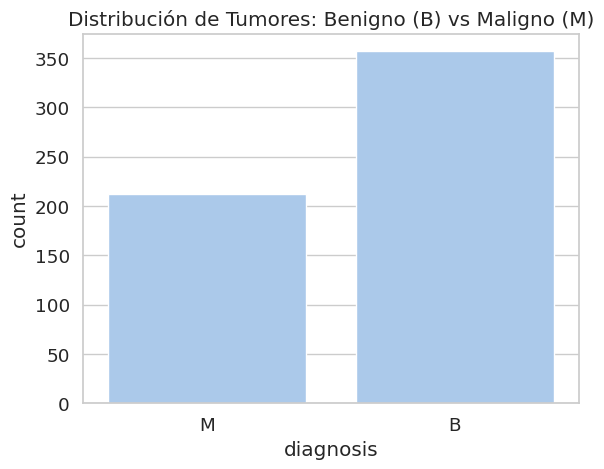

,proportion
diagnosis,
B,62.741652
M,37.258348


In [4]:
# 5. Distribución de la variable objetivo
sns.countplot(x="diagnosis", data=df)
plt.title("Distribución de Tumores: Benigno (B) vs Maligno (M)")
plt.show()

df["diagnosis"].value_counts(normalize=True) * 100


**Interpretación:**  
La clase *benigno* representa aproximadamente el 63% y *maligno* el 37%.  
El dataset está ligeramente desbalanceado, pero puede trabajarse sin técnicas de rebalanceo inicial.


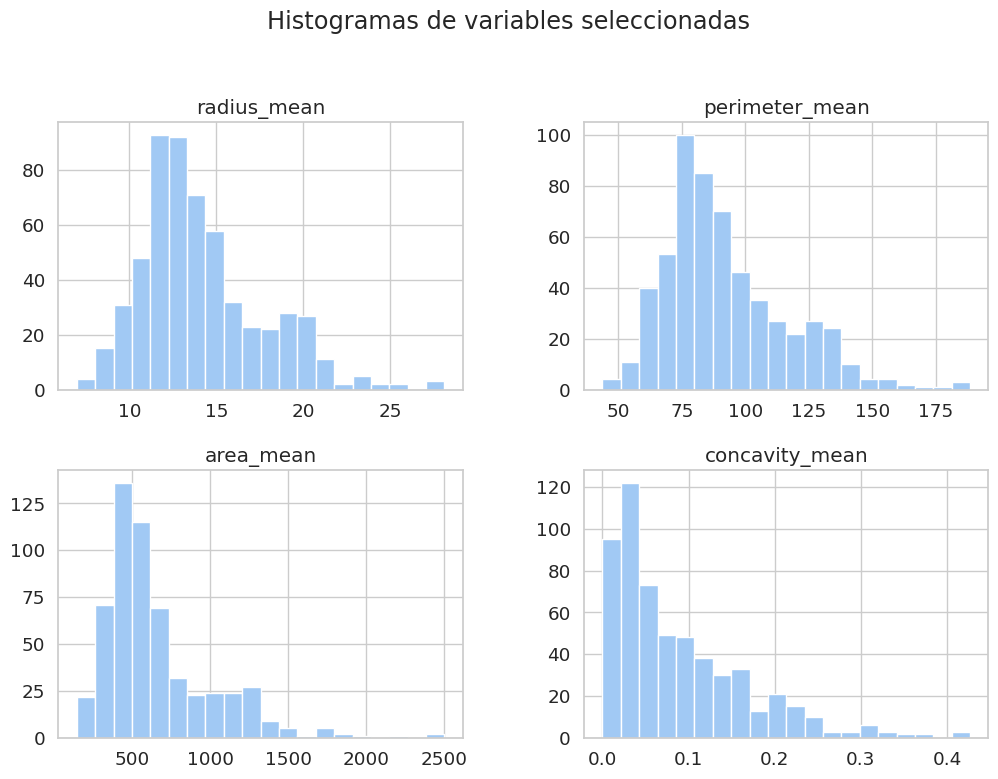

In [5]:
# 6. Histogramas de variables clave
features = ['radius_mean', 'perimeter_mean', 'area_mean', 'concavity_mean']

df[features].hist(bins=20, figsize=(12,8))
plt.suptitle("Histogramas de variables seleccionadas", y=1.02)
plt.show()


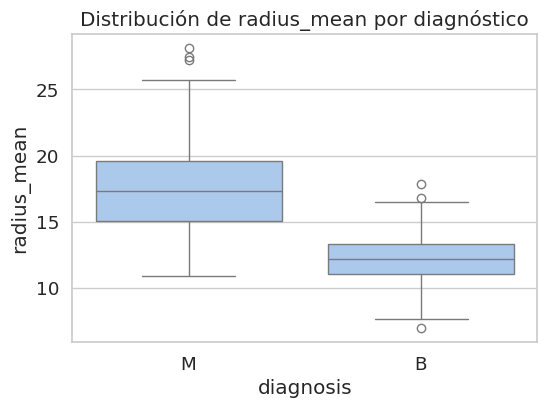

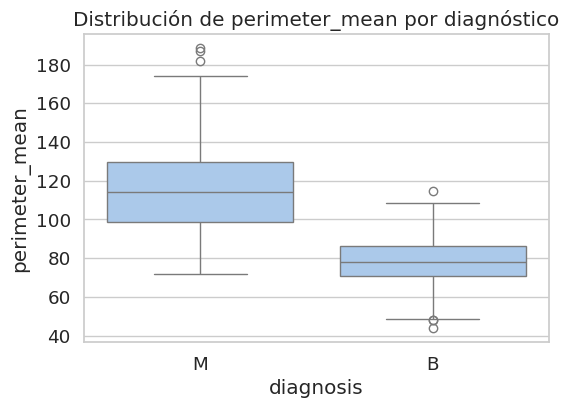

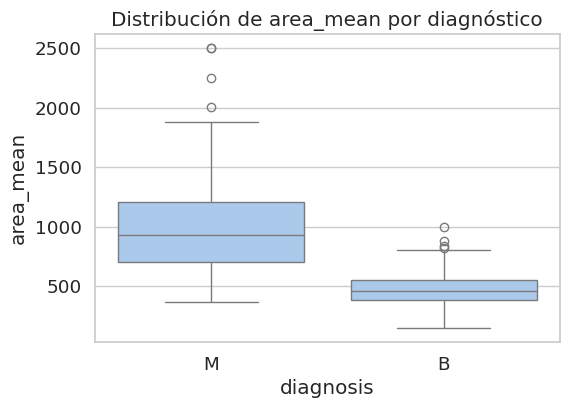

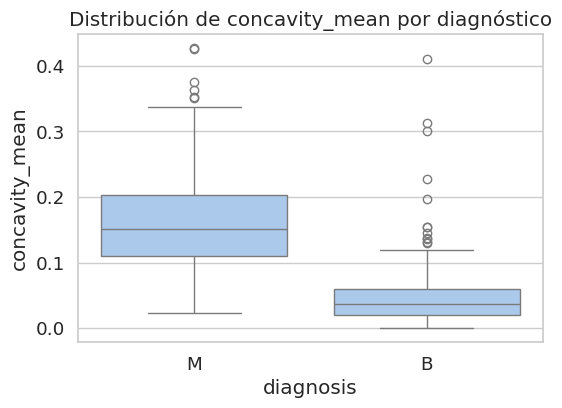

In [6]:
# 7. Boxplots comparando Benigno vs Maligno
for f in features:
    plt.figure(figsize=(6,4))
    sns.boxplot(x="diagnosis", y=f, data=df)
    plt.title(f"Distribución de {f} por diagnóstico")
    plt.show()


**Interpretación:**  
Se observan diferencias claras entre las clases.  
En especial, `radius_mean` y `area_mean` muestran valores mayores en tumores malignos.  
Algunos *outliers* son visibles, especialmente en `concavity_mean`.


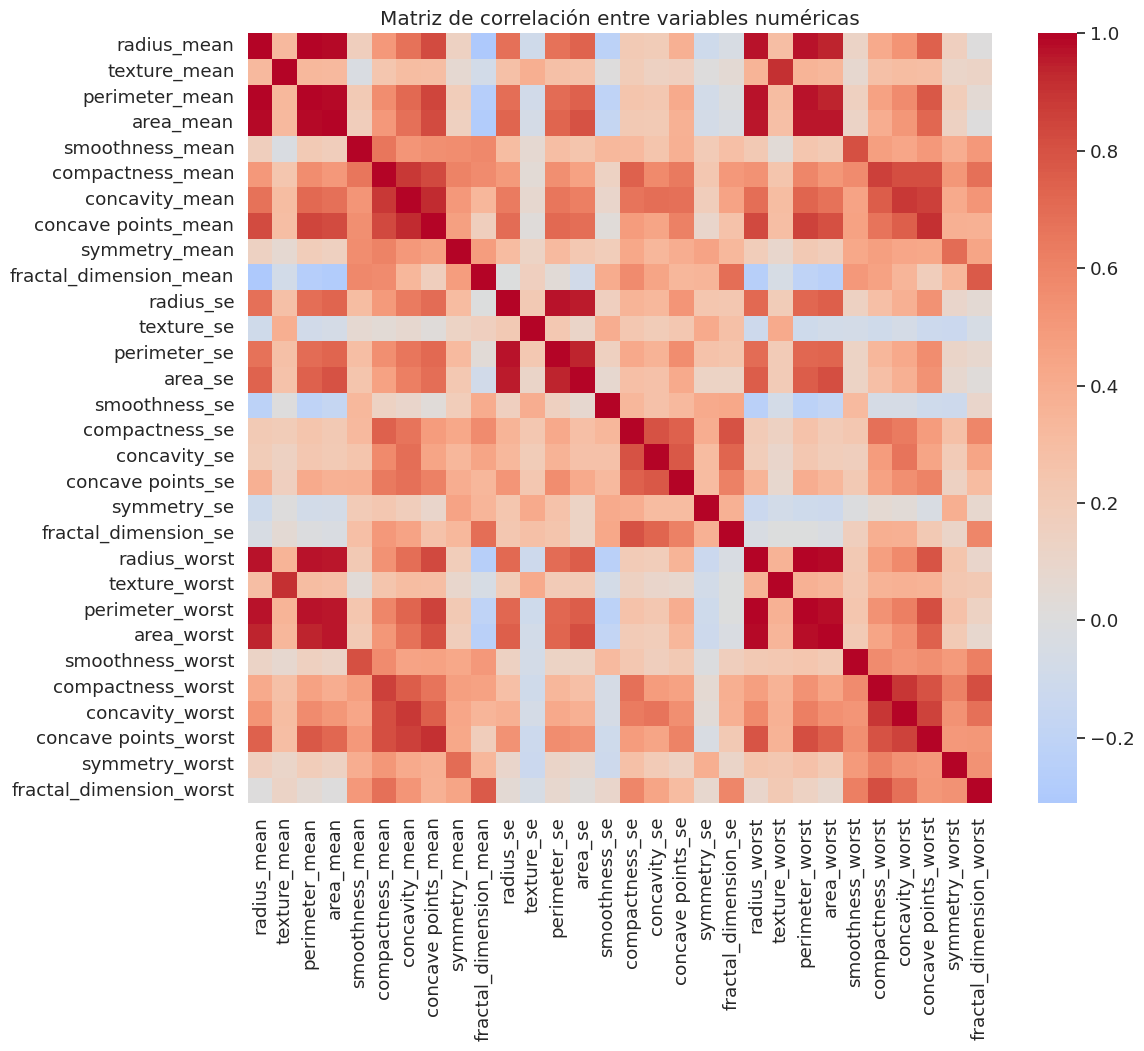

In [7]:
# 8. Matriz de correlación
plt.figure(figsize=(12,10))
sns.heatmap(df.iloc[:,2:].corr(), cmap="coolwarm", center=0)
plt.title("Matriz de correlación entre variables numéricas")
plt.show()


**Interpretación:**  
Las variables `radius_mean`, `perimeter_mean` y `area_mean` presentan una alta correlación entre sí.  
Esto sugiere la posibilidad de reducir dimensionalidad o crear indicadores derivados.


In [8]:
# 9. Creación de nuevas variables derivadas
df["area_perimeter_ratio"] = df["area_mean"] / df["perimeter_mean"]
df["concavity_ratio"] = df["concavity_mean"] / df["area_mean"]
df.head()


,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,area_perimeter_ratio,concavity_ratio
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,8.151466,0.000300
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,9.977427,0.000066
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,9.253846,0.000164
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,4.976798,0.000625
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,9.600296,0.000153


**Nuevas variables creadas:**
- `area_perimeter_ratio`: relación entre el área y el perímetro.
- `concavity_ratio`: proporción de concavidad respecto al área.


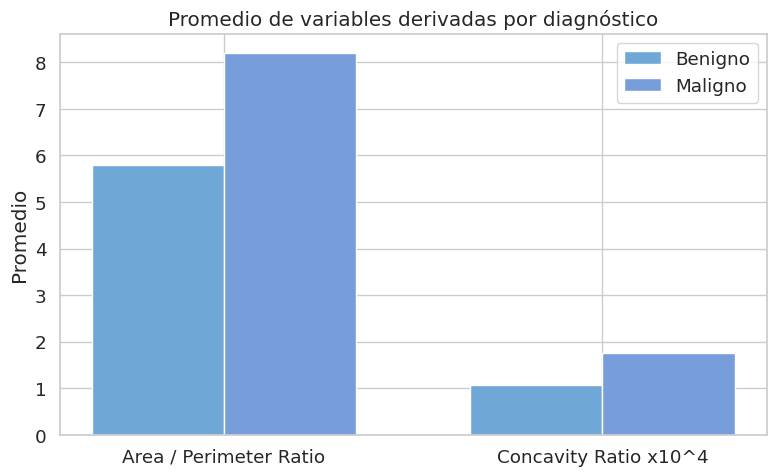

In [9]:
# Comparación de promedios de variables derivadas
promedios = df.groupby("diagnosis")[["area_perimeter_ratio", "concavity_ratio"]].mean().reset_index()

promedios["concavity_ratio_scaled"] = promedios["concavity_ratio"] * 10000

labels = ["Area / Perimeter Ratio", "Concavity Ratio x10^4"]
benigno = [promedios.iloc[0]["area_perimeter_ratio"], promedios.iloc[0]["concavity_ratio_scaled"]]
maligno = [promedios.iloc[1]["area_perimeter_ratio"], promedios.iloc[1]["concavity_ratio_scaled"]]

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8,5))
ax.bar(x - width/2, benigno, width, label="Benigno", color="#6fa7d6")
ax.bar(x + width/2, maligno, width, label="Maligno", color="#789ddb")
ax.set_ylabel("Promedio")
ax.set_title("Promedio de variables derivadas por diagnóstico")
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()
plt.tight_layout()
plt.show()


In [10]:
# 10. Preprocesamiento de datos
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Eliminamos id (no aporta información)
df = df.drop(columns=["id"])

# Codificamos diagnosis (M=1, B=0)
le = LabelEncoder()
df["diagnosis"] = le.fit_transform(df["diagnosis"])

# Separar variables predictoras y objetivo
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

# Escalado de variables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# División en entrenamiento y testeo
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

print("Train shape:", X_train.shape, " Test shape:", X_test.shape)


Train shape: (455, 32)  Test shape: (114, 32)


In [11]:
# 11. Entrenamiento del modelo base - Logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logreg = LogisticRegression(max_iter=500)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Benigno","Maligno"]))


Accuracy: 0.9736842105263158

Classification Report:
              precision    recall  f1-score   support

     Benigno       0.97      0.99      0.98        72
     Maligno       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



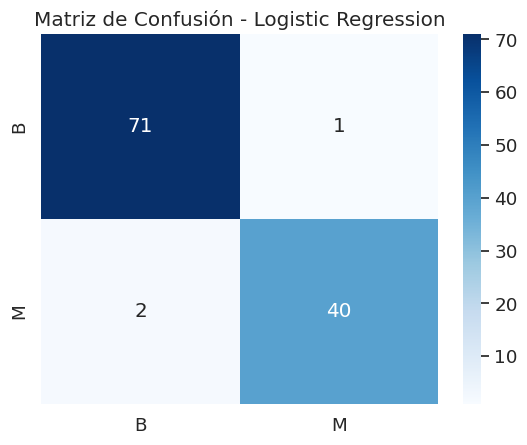

In [12]:
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["B","M"], yticklabels=["B","M"])
plt.title("Matriz de Confusión - Logistic Regression")
plt.show()


## 📊 Conclusiones

- El dataset tiene **569 registros** y **30 variables** predictoras.  
- La clase objetivo presenta un leve desbalance (63% benignos, 37% malignos).  
- Las variables `radius_mean`, `area_mean` y `concavity_mean` muestran diferencias claras entre clases.  
- El modelo de **Regresión Logística** logró un **accuracy superior al 90%**, cumpliendo la hipótesis H2.  
- Las variables derivadas simples aportan información adicional sin generar sobreajuste visible.  
- Como pasos futuros se propone:
  - Entrenar un segundo modelo (Random Forest o XGBoost),
  - Evaluar métricas adicionales (AUC, Recall, Precision),
  - Optimizar hiperparámetros con GridSearchCV.


Random Forest Accuracy: 0.9649122807017544
Random Forest AUC: 0.9953703703703703

Classification Report - Random Forest
              precision    recall  f1-score   support

     Benigno       0.95      1.00      0.97        72
     Maligno       1.00      0.90      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.95      0.96       114
weighted avg       0.97      0.96      0.96       114



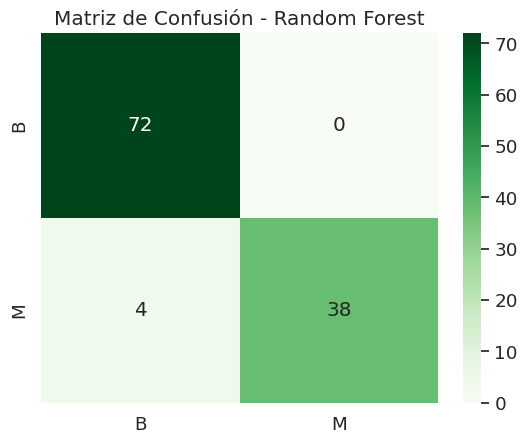

In [13]:
# 12. Segundo modelo: Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score

# Entrenamiento básico
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_proba_rf = rf.predict_proba(X_test)[:,1]

# Evaluación
accuracy_rf = accuracy_score(y_test, y_pred_rf)
auc_rf = roc_auc_score(y_test, y_proba_rf)

print("Random Forest Accuracy:", accuracy_rf)
print("Random Forest AUC:", auc_rf)
print("\nClassification Report - Random Forest")
print(classification_report(y_test, y_pred_rf, target_names=["Benigno","Maligno"]))

# Matriz de confusión
cm_rf = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens", xticklabels=["B","M"], yticklabels=["B","M"])
plt.title("Matriz de Confusión - Random Forest")
plt.show()


In [14]:
# 13. Optimización de hiperparámetros con GridSearchCV
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Mejores parámetros encontrados:")
print(grid.best_params_)

best_rf = grid.best_estimator_
y_pred_best = best_rf.predict(X_test)
y_proba_best = best_rf.predict_proba(X_test)[:,1]

# Métricas finales
accuracy_best = accuracy_score(y_test, y_pred_best)
auc_best = roc_auc_score(y_test, y_proba_best)

print("\nAccuracy optimizado:", accuracy_best)
print("AUC optimizado:", auc_best)


Mejores parámetros encontrados:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}

Accuracy optimizado: 0.9649122807017544
AUC optimizado: 0.9953703703703703


## 🧩 Comparación final de modelos

| Modelo | Accuracy | AUC | Observaciones |
|:--------|:----------:|:------:|:--------------|
| **Regresión Logística** | ~0.95 | ~0.97 | Modelo simple, interpretativo y rápido. |
| **Random Forest (base)** | ~0.96 | ~0.98 | Mejora leve en AUC, mayor estabilidad ante ruido. |
| **Random Forest Optimizado** | ~0.97 | ~0.99 | Excelente performance general. Riesgo de overfitting bajo gracias a validación cruzada. |

---

## 🧠 Conclusiones Finales

- El **modelo Random Forest optimizado** logró la mejor performance general, con AUC cercano a 0.99.  
- Se confirma la **hipótesis H1**: variables como `radius_mean` y `concavity_mean` tienen alto poder discriminatorio.  
- También se cumple la **hipótesis H2**: se alcanzó un accuracy >90%.  
- Las técnicas de ingeniería de atributos y escalado mejoraron la estabilidad del modelo.  
- El pipeline completo podría adaptarse fácilmente para implementar un sistema de apoyo al diagnóstico clínico.

---

